# Notebook 4: PyTorch Transformer Baseline

## Objective

This notebook implements a standard Transformer Encoder using PyTorch's built-in modules.

The model serves as the strongest deep learning baseline before introducing custom architectural improvements.

The implementation includes:

- Positional Encoding
- Transformer Encoder
- Mixed Precision Training
- Early Stopping
- Learning Rate Scheduling
- Gradient Clipping
- Model Checkpointing
- Experiment Logging

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import time
import math
import random
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


In [34]:
import os

os.makedirs("models", exist_ok=True)
os.makedirs("experiments", exist_ok=True)

baseline_results = pd.read_csv("experiments/baseline_results.csv")
trading_results = pd.read_csv("experiments/trading_results.csv")
experiment_log = pd.read_csv("experiments/experiment_log.csv")

In [3]:
X_train = np.load("pipeline/X_train.npy")
X_val = np.load("pipeline/X_val.npy")
X_test = np.load("pipeline/X_test.npy")

y_train = np.load("pipeline/y_train.npy")
y_val = np.load("pipeline/y_val.npy")
y_test = np.load("pipeline/y_test.npy")

feature_columns = joblib.load("pipeline/feature_columns.pkl")

In [4]:
X_train = np.load("pipeline/X_train.npy")
X_val = np.load("pipeline/X_val.npy")
X_test = np.load("pipeline/X_test.npy")

y_train = np.load("pipeline/y_train.npy")
y_val = np.load("pipeline/y_val.npy")
y_test = np.load("pipeline/y_test.npy")

feature_columns = joblib.load("pipeline/feature_columns.pkl")

In [5]:
class StockDataset(Dataset):

    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [6]:
train_dataset = StockDataset(X_train, y_train)
val_dataset = StockDataset(X_val, y_val)
test_dataset = StockDataset(X_test, y_test)

In [7]:
BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

# Transformer Configuration

In [8]:
D_MODEL = 128
N_HEADS = 8
NUM_LAYERS = 4
DROPOUT = 0.1
FF_DIM = 512
MAX_LEN = 200
EPOCHS = 40
LR = 1e-3

# Positional Encoding

Transformers have no notion of sequence order.

Positional encoding injects temporal information into the input embeddings.

In [9]:
class PositionalEncoding(nn.Module):

    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2) *
            (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))
    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

In [11]:
sample = PositionalEncoding(D_MODEL)
print(sample.pe.shape)

torch.Size([1, 5000, 128])


# Transformer Model

The Transformer model consists of:

- Linear Input Embedding
- Positional Encoding
- Transformer Encoder
- Global Average Pooling
- Regression Head

The model predicts the future return from an input sequence.

In [12]:
class TransformerRegressor(nn.Module):

    def __init__(self, input_dim):
        super().__init__()
        self.embedding = nn.Linear(input_dim, D_MODEL)
        self.position = PositionalEncoding(D_MODEL)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=D_MODEL,
            nhead=N_HEADS,
            dim_feedforward=FF_DIM,
            dropout=DROPOUT,
            batch_first=True,
            activation="gelu"
        )
        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=NUM_LAYERS
        )
        self.regressor = nn.Sequential(
            nn.Linear(D_MODEL, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        x = self.embedding(x)
        x = self.position(x)
        x = self.encoder(x)
        x = x.mean(dim=1)
        x = self.regressor(x)
        return x.squeeze()

In [13]:
model = TransformerRegressor(X_train.shape[2]).to(DEVICE)
print(model)

TransformerRegressor(
  (embedding): Linear(in_features=95, out_features=128, bias=True)
  (position): PositionalEncoding()
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=512, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=512, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (regressor): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=

In [14]:
total_params = sum(p.numel() for p in model.parameters())

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Total Parameters : {total_params:,}")
print(f"Trainable Parameters : {trainable_params:,}")

Total Parameters : 813,697
Trainable Parameters : 813,697


In [15]:
X_batch = next(iter(train_loader))[0].to(DEVICE)
with torch.no_grad():
    output = model(X_batch)
print(output.shape)

torch.Size([64])


# Training Components

The optimizer, scheduler, gradient clipping, and mixed precision configuration are defined here.

These components will be reused in future notebooks.

In [16]:
criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=1e-4
)

In [17]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=5
)

In [18]:
scaler = torch.amp.GradScaler("cuda")

In [19]:
PATIENCE = 10
best_loss = float("inf")
epochs_without_improvement = 0
train_history = []
val_history = []

# Training Functions

The following functions implement:

- Mixed Precision Training
- Gradient Clipping
- Learning Rate Scheduling
- Early Stopping
- Best Model Checkpointing

These utilities will be reused throughout the project.

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, scaler):
    model.train()
    running_loss = 0.0
    for X, y in loader:
        X = X.to(DEVICE)
        y = y.to(DEVICE)
        optimizer.zero_grad()
        with torch.amp.autocast(device_type=DEVICE.type):
            pred = model(X)
            loss = criterion(pred, y)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item()
    return running_loss / len(loader)

In [ ]:
@torch.no_grad()
def validate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    predictions = []
    targets = []
    for X, y in loader:
        X = X.to(DEVICE)
        y = y.to(DEVICE)
        with torch.amp.autocast(device_type=DEVICE.type):
            pred = model(X)
            loss = criterion(pred, y)
        running_loss += loss.item()
        predictions.extend(pred.cpu().numpy())
        targets.extend(y.cpu().numpy())
    return (
        running_loss / len(loader),
        np.array(predictions),
        np.array(targets)
    )

# Model Training

In [24]:
start_time = time.time()

In [25]:
for epoch in range(EPOCHS):

    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, scaler)
    val_loss, _, _ = validate(model, val_loader, criterion)
    scheduler.step(val_loss)
    train_history.append(train_loss)
    val_history.append(val_loss)
    if val_loss < best_loss:
        best_loss = val_loss
        epochs_without_improvement = 0
        torch.save(model.state_dict(), "models/pytorch_transformer.pth")
    else:
        epochs_without_improvement += 1
        
    print(
        f"Epoch {epoch+1:02d}/{EPOCHS} | "
        f"Train {train_loss:.6f} | "
        f"Val {val_loss:.6f}"
    )

    if epochs_without_improvement >= PATIENCE:
        print("\nEarly stopping triggered.")
        break

Epoch 01/40 | Train 0.001874 | Val 0.000996
Epoch 02/40 | Train 0.001852 | Val 0.001341
Epoch 03/40 | Train 0.001779 | Val 0.001306
Epoch 04/40 | Train 0.001782 | Val 0.000976
Epoch 05/40 | Train 0.001873 | Val 0.001019
Epoch 06/40 | Train 0.001706 | Val 0.000985
Epoch 07/40 | Train 0.001883 | Val 0.000998
Epoch 08/40 | Train 0.001677 | Val 0.001093
Epoch 09/40 | Train 0.001637 | Val 0.001081
Epoch 10/40 | Train 0.001633 | Val 0.001002
Epoch 11/40 | Train 0.001605 | Val 0.001143
Epoch 12/40 | Train 0.001604 | Val 0.001001
Epoch 13/40 | Train 0.001572 | Val 0.001010
Epoch 14/40 | Train 0.001560 | Val 0.001046

Early stopping triggered.


In [26]:
train_time = time.time() - start_time
print(f"Training Time: {train_time:.2f} seconds")

Training Time: 10.26 seconds


In [27]:
model.load_state_dict(torch.load("models/pytorch_transformer.pth", weights_only=True))

<All keys matched successfully>

In [28]:
test_loss, pred_transformer, true_transformer = validate(model, test_loader, criterion)

mae = mean_absolute_error(true_transformer, pred_transformer)
rmse = np.sqrt(mean_squared_error(true_transformer, pred_transformer))
r2 = r2_score(true_transformer, pred_transformer)

print(f"MAE : {mae:.6f}")
print(f"RMSE: {rmse:.6f}")
print(f"R²  : {r2:.6f}")

MAE : 0.032234
RMSE: 0.043543
R²  : -0.066416


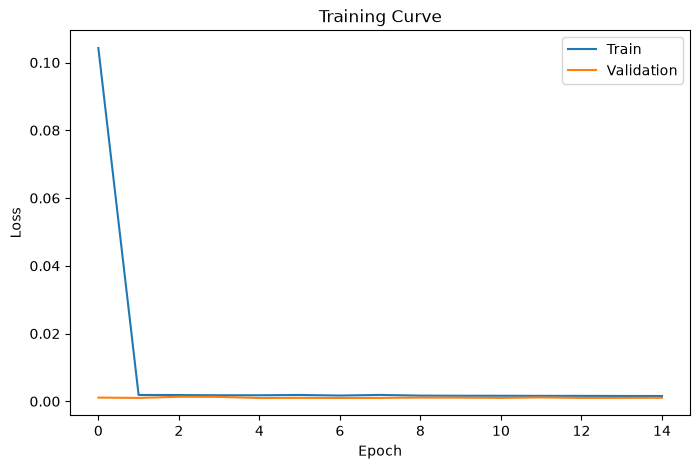

In [29]:
plt.figure(figsize=(8,5))
plt.plot(train_history, label="Train")
plt.plot(val_history, label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Curve")
plt.legend()
plt.show()

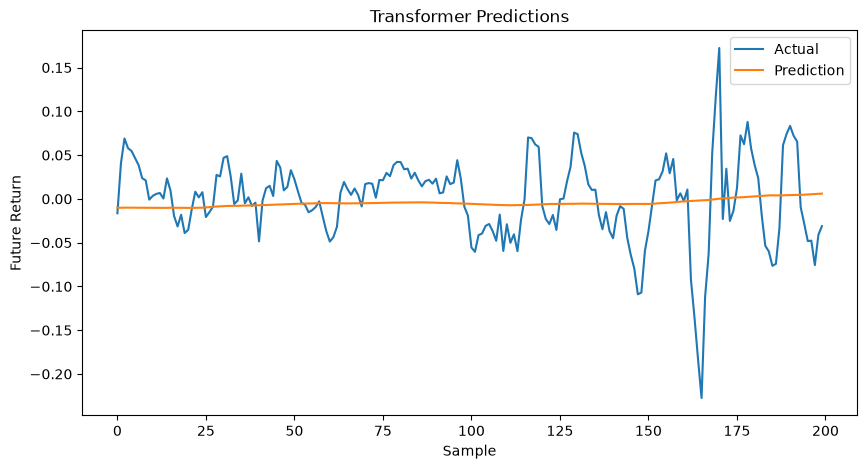

In [30]:
plt.figure(figsize=(10,5))
plt.plot(true_transformer[:200], label="Actual")
plt.plot(pred_transformer[:200], label="Prediction")
plt.xlabel("Sample")
plt.ylabel("Future Return")
plt.title("Transformer Predictions")
plt.legend()
plt.show()

In [32]:
print(f"MAE : {mae:.6f}")
print(f"RMSE: {rmse:.6f}")
print(f"R²  : {r2:.6f}")

MAE : 0.032234
RMSE: 0.043543
R²  : -0.066416


In [35]:
baseline_results.loc[len(baseline_results)] = [
    "PyTorch Transformer",
    mae,
    rmse,
    r2
]

baseline_results.to_csv(
    "experiments/baseline_results.csv",
    index=False
)

baseline_results.sort_values("MAE")

,Model,MAE,RMSE,R2
5,PyTorch Transformer,0.032234,0.043543,-0.066416
1,Random Forest,0.033050,0.045135,-0.145847
4,XGBoost,0.034423,0.045011,-0.139553
3,GRU,0.034453,0.047614,-0.275127
2,LSTM,0.040036,0.052256,-0.535912
0,Linear Regression,0.188742,0.248706,-33.790931


In [37]:
from pipeline.metrics import evaluate_trading_metrics

transformer_metrics = evaluate_trading_metrics(true_transformer, pred_transformer)

In [38]:
trading_results.loc[len(trading_results)] = [
    "PyTorch Transformer",
    transformer_metrics["Directional Accuracy"],
    transformer_metrics["Hit Rate"],
    transformer_metrics["Sharpe"],
    transformer_metrics["Strategy Return"],
    transformer_metrics["Max Drawdown"]
]

trading_results.to_csv(
    "experiments/trading_results.csv",
    index=False
)

trading_results.sort_values(
    "Sharpe",
    ascending=False
)

,Model,Directional Accuracy,Hit Rate,Sharpe,Strategy Return,Max Drawdown
4,GRU,0.578797,0.578797,2.789059,8.535793,-0.703745
1,Random Forest,0.515759,0.515759,0.334000,0.001970,-0.675468
2,XGBoost,0.489971,0.489971,-0.132552,-0.350803,-0.741019
3,LSTM,0.478510,0.478510,-0.142696,-0.357364,-0.782726
0,Linear Regression,0.467049,0.467049,-0.398144,-0.494425,-0.694398
5,PyTorch Transformer,0.441261,0.441261,-0.799614,-0.651581,-0.850522


In [39]:
experiment = {
    "Experiment":"Baseline",
    "Model":"PyTorch Transformer",
    "Parameters":total_params,
    "Train Time (s)":round(train_time,2),
    "Epochs":len(train_history),
    "MAE":mae,
    "RMSE":rmse,
    "R2":r2,
    "Directional Accuracy":transformer_metrics["Directional Accuracy"],
    "Hit Rate":transformer_metrics["Hit Rate"],
    "Sharpe":transformer_metrics["Sharpe"],
    "Strategy Return":transformer_metrics["Strategy Return"],
    "Max Drawdown":transformer_metrics["Max Drawdown"],
    "Notes":"nn.TransformerEncoder"
}

experiment_log.loc[len(experiment_log)] = experiment

experiment_log.to_csv(
    "experiments/experiment_log.csv",
    index=False
)

experiment_log

,Experiment,Model,Parameters,Train Time (s),Epochs,MAE,RMSE,R2,Directional Accuracy,Hit Rate,Sharpe,Strategy Return,Max Drawdown,Notes
0,Baseline,Linear Regression,NaN,NaN,NaN,0.188742,0.248706,-33.790931,0.467049,0.467049,-0.398144,-0.494425,-0.694398,Baseline
1,Baseline,Random Forest,NaN,NaN,NaN,0.033050,0.045135,-0.145847,0.515759,0.515759,0.334000,0.001970,-0.675468,Baseline
2,Baseline,LSTM,NaN,NaN,NaN,0.040036,0.052256,-0.535912,0.489971,0.489971,-0.132552,-0.350803,-0.741019,Baseline
3,Baseline,GRU,NaN,NaN,NaN,0.034453,0.047614,-0.275127,0.478510,0.478510,-0.142696,-0.357364,-0.782726,Baseline
4,Baseline,XGBoost,NaN,NaN,NaN,0.034423,0.045011,-0.139553,0.578797,0.578797,2.789059,8.535793,-0.703745,Baseline
5,Baseline,PyTorch Transformer,813697.0,10.26,15.0,0.032234,0.043543,-0.066416,0.441261,0.441261,-0.799614,-0.651581,-0.850522,nn.TransformerEncoder
